#### spateGAN-ERA5 spatiotemporal precipitation downscaling example
https://www.nature.com/articles/s41612-025-01103-y

In [39]:
%load_ext autoreload
%autoreload 2
import torch
import xarray as xr
import numpy as np
from einops import rearrange
import sys
import os
import pathlib
import matplotlib.pyplot as plt
from matplotlib import gridspec
sys.path.append(os.path.abspath("../"))

from src.spategan_era5.model import Generator
from src.spategan_era5.inference import InferenceEngine

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [40]:
project_root = pathlib.Path(os.getcwd()).parent
model_path = project_root / 'model_weights' / 'model_weights.pt' # Path to the model weights
fn_test_y = project_root / 'data' / 'validation_data' / 'y_val.nc' # Validation targets
fn_test_x = project_root / 'data' / 'validation_data' / 'x_val.nc' # Validation inputs

In [41]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

cuda


#### load model and weights

In [42]:
spateGAN_era5 = Generator().to(device)

In [43]:
# Load the state_dict
checkpoint = torch.load(model_path, weights_only=True)
spateGAN_era5.load_state_dict(checkpoint, strict=True)
spateGAN_era5.eval()
print("Model weights loaded successfully.")

Model weights loaded successfully.


#### Load example dataset
Model expects ERA5 input data, projected to a regular 24x24 km grid. \
Target radar observations lay on a regular 2x2 km grid, 10 min. resolution

In [44]:
# Keep the 500-sample files lazy and load only one paired sample.
ds_test_y = xr.open_dataset(fn_test_y).load()
ds_test_x = xr.open_dataset(fn_test_x).load()

MemoryError: Unable to allocate 10.1 GiB for an array with shape (500, 96, 336, 336) and data type int16

In [ ]:
x_test = np.stack([ds_test_x.cp.values, ds_test_x.lsp.values])
x_test = rearrange(x_test, 'c t h w -> 1 c t h w')
y_test = rearrange(ds_test_y.sample_high_res.values, 't h w -> 1 1 t h w')

In [ ]:
x_test.shape, y_test.shape

((1, 2, 16, 28, 28), (1, 1, 96, 336, 336))

#### Downscale data to 2x2km & 10 min resolution

Patchsizes:\
x: (batch, channels, time, width, height) = (batch, 2, 16, 28, 28) = (batch, CP & LSP, 16hr, 672km, 672km) \
y: (batch, channels, time, width, height) = (batch, 1, 48, 168, 168) = (batch,TP, 8hr, 336km, 336km) --> cropped to (batch,TP, 6hr, 288km, 288km)

In [ ]:
# Initialize InferenceEngine
engine = InferenceEngine(spateGAN_era5)

In [ ]:
# Perform inference
prediction, target, era5 = engine.infer(x_test, target=y_test, seed=4)

#### Plot results

In [ ]:
timestep = 100
vmax = 20
vmin = 0.01

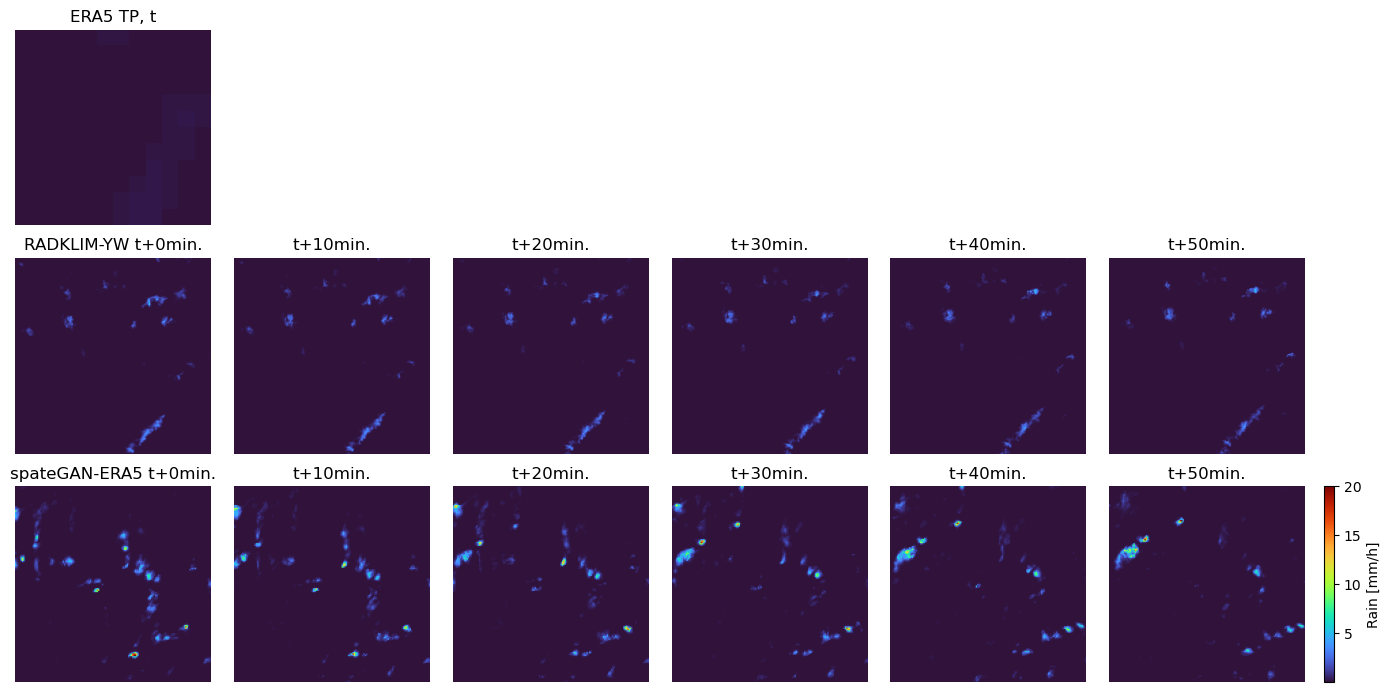

In [ ]:
fig = plt.figure(figsize=(14, 7))
gs = gridspec.GridSpec(3, 7, figure=fig, width_ratios=[1]*6 + [0.05])

# Plot ERA5 TP data
ax = fig.add_subplot(gs[0,0])
img = ax.imshow(era5[timestep//6], cmap='turbo', vmin=vmin, vmax=vmax)
ax.set_title(f"ERA5 TP, t")
ax.axis('off') 

axes_tar = []
for j in range(6):
    ax = fig.add_subplot(gs[1, j])
    axes_tar.append(ax)

axes_pred = []
for j in range(6):
    ax = fig.add_subplot(gs[2, j])
    axes_pred.append(ax)


# Plot RADKLIM-YW data
for i, ax in enumerate(axes_tar):
    img = ax.imshow(target[timestep+i], cmap='turbo', vmin=vmin, vmax=vmax)
    if i == 0:
        ax.set_title(f"RADKLIM-YW t+{i*10}min.")
    else:
        ax.set_title(f"t+{i*10}min.")
    ax.axis('off') 

# Plot predictions
for i, ax in enumerate(axes_pred):
    img = ax.imshow(prediction[timestep+i], cmap='turbo', vmin=vmin, vmax=vmax)
    if i == 0:
        ax.set_title(f"spateGAN-ERA5 t+{i*10}min.")
    else:
        ax.set_title(f"t+{i*10}min.")
    ax.axis('off')  

# Add the colorbar
colorbar_ax = fig.add_subplot(gs[-1, 6]) 
fig.colorbar(img, cax=colorbar_ax, label='Rain [mm/h]')  

plt.tight_layout()
plt.show()